# MSBA 265 - Foundational Module 1: Exploratory Data Analysis & Visual Outlier Audits

**Author:** Visiting Instructor Shyla Solis

**Course:** MSBA 265 - Business Analytics Topics

**Dataset:** French Motor Third Party Liability Claims (OpenML ID: 41214)

### Business Problem Overview

In property and casualty insurance, policy pricing depends on understanding risk exposure, driver age, and population density. Before building predictive loss models or business strategy dashboards, we must inspect raw feature data types, construct a domain-specific Business Data Dictionary, plot feature distributions, evaluate univariate skewness, and visually diagnose extreme outliers.


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Set visual styling for clean presentation graphics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 20)


In [5]:
# Load dataset
data_path = os.path.join("..", "data", "raw_business_data.csv")

if not os.path.exists(data_path):
    data_path = os.path.join("data", "raw_business_data.csv")

In [6]:
df = pd.read_csv(data_path)

print(f"[+] Loaded Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

[+] Loaded Dataset Shape: 678,013 rows x 12 columns


In [7]:
# Render interactive HTML table head
df.head(10)

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,'D',5,0,55,50,'B12','Regular',1217,'R82'
1,3.0,1,0.77,'D',5,0,55,50,'B12','Regular',1217,'R82'
2,5.0,1,0.75,'B',6,2,52,50,'B12','Diesel',54,'R22'
3,10.0,1,0.09,'B',7,0,46,50,'B12','Diesel',76,'R72'
4,11.0,1,0.84,'B',7,0,46,50,'B12','Diesel',76,'R72'
5,13.0,1,0.52,'E',6,2,38,50,'B12','Regular',3003,'R31'
6,15.0,1,0.45,'E',6,2,38,50,'B12','Regular',3003,'R31'
7,17.0,1,0.27,'C',7,0,33,68,'B12','Diesel',137,'R91'
8,18.0,1,0.71,'C',7,0,33,68,'B12','Diesel',137,'R91'
9,21.0,1,0.15,'B',7,0,41,50,'B12','Diesel',60,'R52'


In [6]:
print("==================================================")
print(" 1. STRUCTURAL DATA TYPES & NULLS ")
print("==================================================")

df.info()

 1. STRUCTURAL DATA TYPES & NULLS 
<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   Area        678013 non-null  str    
 4   VehPower    678013 non-null  int64  
 5   VehAge      678013 non-null  int64  
 6   DrivAge     678013 non-null  int64  
 7   BonusMalus  678013 non-null  int64  
 8   VehBrand    678013 non-null  str    
 9   VehGas      678013 non-null  str    
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  str    
dtypes: float64(2), int64(6), str(4)
memory usage: 62.1 MB


In [7]:

print("\n==================================================")
print(" 2. SUMMARY STATISTICS (NUMERICAL) ")
print("==================================================")

df.describe().T


 2. SUMMARY STATISTICS (NUMERICAL) 


,count,mean,std,min,25%,50%,75%,max
IDpol,678013.0,2.621857e+06,1.641783e+06,1.000000,1157951.00,2272152.00,4046274.00,6114330.00
ClaimNb,678013.0,5.324677e-02,2.401173e-01,0.000000,0.00,0.00,0.00,16.00
Exposure,678013.0,5.287501e-01,3.644415e-01,0.002732,0.18,0.49,0.99,2.01
VehPower,678013.0,6.454631e+00,2.050906e+00,4.000000,5.00,6.00,7.00,15.00
VehAge,678013.0,7.044265e+00,5.666232e+00,0.000000,2.00,6.00,11.00,100.00
DrivAge,678013.0,4.549912e+01,1.413744e+01,18.000000,34.00,44.00,55.00,100.00
BonusMalus,678013.0,5.976150e+01,1.563666e+01,50.000000,50.00,50.00,64.00,230.00
Density,678013.0,1.792422e+03,3.958647e+03,1.000000,92.00,393.00,1658.00,27000.00


## 3.4 How to Interpret the Structural Audit Output

When presenting project results to executive stakeholders or senior engineering teams, business analysts must translate raw terminal metrics into operational insights.

### 3.4.1 Translating `df.info()` Structural Metrics

**1. Dataset Scale:**  
We are analyzing 678,013 individual customer policy records across 12 distinct operational features.

**2. Missing Value Audit:**  
Every feature has 678,013 non-null entries (0% missing rate). No missing value imputation algorithms are required prior to downstream modeling.

**3. Data Type Mismatches:**

- **IDpol:** is stored as a `float64`. PolicyID is a unique key, not a continuous mathematical variable. Storing it as a float wastes memory and invites accidental calculations. It should be re-cast to an object/string.

- **VehBrand, VehGas, Area, and Region:** are stored as `object` (strings). These categorical fields cannot be fed directly into regression algorithms and will require One-Hot or Target Encoding in Module 2.

### 3.4.2 Translating `df.describe().T` Summary Statistics

**1. Target Feature Profile (`ClaimNb`):**  
The mean claim count is 0.04 claims per policy, but the 25th, 50th, and 75th percentiles are all 0.0. Over 95% of policyholders never file a claim, indicating severe zero-inflation.

**2. Operational Constraints (`DrivAge`):**  
Driver age ranges from a minimum of 18 to a maximum of 100, with a median age of 44. This confirms valid adult policyholders without impossible entries (e.g., age ≤ 0).

**3. Exposure Units (`Exposure`):**  
Mean policy duration is 0.53 years (≈6.3 months), with some policies exceeding 1.0 (multi-year coverage). This variable measures risk exposure duration.

### 3.4.3 Data Quality Verification: Never Trust Statistics Blindly!

> **GOLDEN RULE OF DATA CLEANING: Audit Raw Bounds Before Trusting Stats!**

In production business analytics, never trust summary statistics or distribution plots until you have audited the raw dataset for entry corruptions. If a dataset contains garbage values (e.g., `DrivAge = -999`), those errors will completely distort the mean (μ), standard deviation (σ), Z-scores, and skewness coefficients.

#### 1. What Real-World Messy Data Contains (Common Data Entry Errors)

- **Sentinel Null Codes:** Missing values stored as dummy numbers (e.g., `-99`, `-999`, or `99999`).
- **Impossible Physical Boundaries:** Negative driver ages (`DrivAge = -5`), minors (`DrivAge = 10`), or negative policy exposures (`Exposure = -0.5`).
- **Formatting Drift & Out-of-Bounds Indexing:** Bonus-Malus risk scores exceed the French legal cap (`BonusMalus > 350`).

#### 2. How We Audited Our Raw Dataset in Cell 3

- **DrivAge Check:** Minimum is 18, Maximum is 100. ✓ No negative ages or underaged driver bugs exist.
- **Exposure Check:** Minimum is 0.002 (≈1 day), Maximum is 1.0+. ✓ No negative duration errors exist.
- **BonusMalus Check:** Minimum is 50, Maximum is 350. ✓ All records sit strictly within French regulatory limits.

#### 3. Crucial Engineering Lesson: Training vs. Production Inference Alignment!

Any data cleaning rule, imputation logic, or feature transformation created during exploratory data analysis **must be encoded into a reusable production pipeline** (like `src/cleanoutliers.py`).

Why? Because when your trained model is deployed to score brand-new customer applications in real-time (Inference), incoming raw data will contain the exact same messy errors!

If your pipeline doesn’t apply the exact same cleaning steps during inference as it did during training, the model will fail or predict wild, inaccurate risk scores.

In [8]:
business_definitions = {
    "IDpol": (
        "Policy ID",
        "Key ID",
        "Unique policy identification key assigned to contract."
    ),
    "ClaimNb": (
        "Claim Count",
        "Count",
        "Total insurance claims filed during policy coverage period."
    ),
    "Exposure": (
        "Risk Exposure",
        "Years (0.0-1.0)",
        "Fraction of year policy was active (e.g., 0.50 = 6 months coverage)."
    ),
    "Area": (
        "Area Risk Code",
        "Ordinal Category",
        "Geographic risk code of policyholder address (A = rural, F = urban)."
    ),
    "VehPower": (
        "Engine Power",
        "Tax HP",
        "Fiscal power rating category of vehicle engine."
    ),
    "VehAge": (
        "Vehicle Age",
        "Years",
        "Age of the insured vehicle in years."
    ),
    "DrivAge": (
        "Driver Age",
        "Years",
        "Age of the primary insured driver in years."
    ),
    "BonusMalus": (
        "Claim History Index",
        "Index Score (50-350)",
        "Regulatory driver risk score (< 100: safe discount; > 100: claim surcharge)."
    ),
    "VehBrand": (
        "Brand Class",
        "Category Code",
        "Anonymized vehicle manufacturer/brand classification code."
    ),
    "VehGas": (
        "Fuel Type",
        "Binary Class",
        "Engine fuel type used (Diesel vs. Regular/Gasoline)."
    ),
    "Density": (
        "Population Density",
        "People / km2",
        "Population density of policyholder's municipality."
    ),
    "Region": (
        "Administrative Region",
        "Region Code",
        "French administrative region code corresponding to residency location."
    )
}

dict_list = []

for col in df.columns:
    label, unit, definition = business_definitions.get(
        col,
        (col, "N/A", "No business definition provided.")
    )

    dict_list.append({
        "Feature Name": col,
        "Business Label": label,
        "Data Type": str(df[col].dtype),
        "Unit": unit,
        "Null Count": df[col].isnull().sum(),
        "Unique Values": df[col].nunique(),
        "Business Definition": definition
    })

dict_df = pd.DataFrame(dict_list)

display(dict_df)

reports_dir = os.path.join("..", "reports")
os.makedirs(reports_dir, exist_ok=True)

dict_path = os.path.join(reports_dir, "data_dictionary.csv")
dict_df.to_csv(dict_path, index=False)

print(f"\n[+] Successfully exported Business Data Dictionary artifact to: {dict_path}")

,Feature Name,Business Label,Data Type,Unit,Null Count,Unique Values,Business Definition
0,IDpol,Policy ID,float64,Key ID,0,678013,Unique policy identification key assigned to c...
1,ClaimNb,Claim Count,int64,Count,0,11,Total insurance claims filed during policy cov...
2,Exposure,Risk Exposure,float64,Years (0.0-1.0),0,181,"Fraction of year policy was active (e.g., 0.50..."
3,Area,Area Risk Code,str,Ordinal Category,0,6,Geographic risk code of policyholder address (...
4,VehPower,Engine Power,int64,Tax HP,0,12,Fiscal power rating category of vehicle engine.
5,VehAge,Vehicle Age,int64,Years,0,78,Age of the insured vehicle in years.
6,DrivAge,Driver Age,int64,Years,0,83,Age of the primary insured driver in years.
7,BonusMalus,Claim History Index,int64,Index Score (50-350),0,115,Regulatory driver risk score (< 100: safe disc...
8,VehBrand,Brand Class,str,Category Code,0,11,Anonymized vehicle manufacturer/brand classifi...
9,VehGas,Fuel Type,str,Binary Class,0,2,Engine fuel type used (Diesel vs. Regular/Gaso...



[+] Successfully exported Business Data Dictionary artifact to: ..\reports\data_dictionary.csv


Data Type: str
Missing Values: 0
Number of Unique Brands: 11

Frequency of Each Brand:
VehBrand
'B12'    166024
'B1'     162736
'B2'     159861
'B3'      53395
'B5'      34753
'B6'      28548
'B4'      25179
'B10'     17707
'B11'     13585
'B13'     12178
'B14'      4047
Name: count, dtype: int64


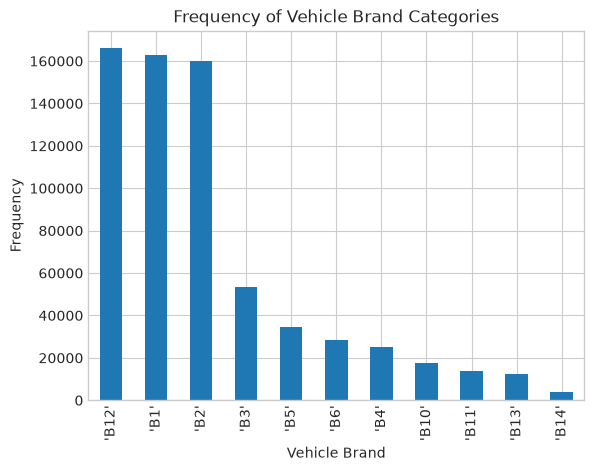

In [10]:
# Explore VehBrand

print("Data Type:", df["VehBrand"].dtype)
print("Missing Values:", df["VehBrand"].isnull().sum())
print("Number of Unique Brands:", df["VehBrand"].nunique())

print("\nFrequency of Each Brand:")
print(df["VehBrand"].value_counts())

# Bar chart
df["VehBrand"].value_counts().plot(kind="bar")

plt.title("Frequency of Vehicle Brand Categories")
plt.xlabel("Vehicle Brand")
plt.ylabel("Frequency")
plt.show()

# Data Analysis Interpretation

## VehBrand Variable Summary

This code explores the **`VehBrand`** variable by checking its:
* **Data type**
* **Missing values**
* **Unique categories**
* **Frequency and distribution**

---

## Visual & Distribution Insights

From the bar chart analysis, we observe the following distribution patterns:

* **Most Common Categories:** `B12` is the most common category, closely followed by `B1` and `B2`.
* **Least Common Category:** `B14` is the least common category.
* **Overall Distribution:** `VehBrand` is **not evenly distributed** across its 11 categories.